 1. Import Dependencies

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import SMOTE

2. Loading LoadStats dataset

In [2]:
data= pd.read_csv('LoanStats3a.csv', encoding='latin-1', low_memory=False)
print(data.shape)
data.head()

(42537, 56)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,1077501,1296599.0,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,Jul-16,0.0,NaN,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0
1,1077430,1314167.0,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,Sep-13,0.0,NaN,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0
2,1077175,1313524.0,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,Jul-16,0.0,NaN,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0
3,1076863,1277178.0,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,Apr-16,0.0,NaN,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0
4,1075358,1311748.0,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,Jul-16,0.0,NaN,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0


3. Data cleaning and Preprocessing

In [3]:
print("\nData Types of each column:\n", data.dtypes)


Data Types of each column:
 id                              object
member_id                      float64
loan_amnt                      float64
funded_amnt                    float64
funded_amnt_inv                float64
term                            object
int_rate                        object
installment                    float64
grade                           object
sub_grade                       object
emp_title                       object
emp_length                      object
home_ownership                  object
annual_inc                     float64
verification_status             object
issue_d                         object
loan_status                     object
pymnt_plan                      object
purpose                         object
title                           object
zip_code                        object
addr_state                      object
dti                            float64
delinq_2yrs                    float64
earliest_cr_line                obj

3.1 Dealing with Null / NAN values

In [4]:
# Check for missing values
data.isna().sum()

,0
id,1
member_id,2
loan_amnt,2
funded_amnt,2
funded_amnt_inv,2
term,2
int_rate,2
installment,2
grade,2
sub_grade,2


In [5]:
# Based on the data dictionary, we will drop the following columns first: emp_title, emp_length, mths_since_last_delinq, mths_since_last_record, next_pymnt_d, mths_since_last_major_derog
df_drop1=data.drop(columns=['emp_title', 'emp_length', 'mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog'],axis=1)
# Check for missing values again
df_drop1.isna().sum()

,0
id,1
member_id,2
loan_amnt,2
funded_amnt,2
funded_amnt_inv,2
term,2
int_rate,2
installment,2
grade,2
sub_grade,2


In [6]:
#Checking for pub_rec_bankruptcies
data['pub_rec_bankruptcies'].value_counts() #Most of the values are 0, so we can drop this column
df_drop2=df_drop1.drop(columns=['pub_rec_bankruptcies'],axis=1)
# Check for missing values again
df_drop2.isna().sum()

,0
id,1
member_id,2
loan_amnt,2
funded_amnt,2
funded_amnt_inv,2
term,2
int_rate,2
installment,2
grade,2
sub_grade,2


In [7]:
#Checking the shape of the data
print("\nShape of the data before dropping missing values:\n", df_drop2.shape)


Shape of the data before dropping missing values:
 (42537, 49)


In [8]:
#Removing rows with missing values, we can also use imputation but for now we will drop them - max drop could be 147 as per above
df_drop3=df_drop2.dropna(axis=0)
# Check for missing values again
df_drop3.isna().sum()

,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0


In [9]:
#Getting the number of rows dropped
print("\nNumber of rows dropped from dataset:", df_drop2.shape[0]-df_drop3.shape[0])
#Checking the shape of the data
print("\nShape of the data after dropping missing values:\n", df_drop3.shape)


Number of rows dropped from dataset: 299

Shape of the data after dropping missing values:
 (42238, 49)


In [10]:
# Checking for duplicate rows
duplicates = df_drop3[df_drop3.duplicated()]
num_duplicates = len(duplicates)
print(f"Number of duplicate rows: {num_duplicates}")

# Remove duplicate rows
df_dropdup = df_drop3.drop_duplicates()
print("Shape of dataset including duplicates",df_drop3.shape)
print("Shape of dataset after removing duplicates",df_dropdup.shape)

Number of duplicate rows: 0
Shape of dataset including duplicates (42238, 49)
Shape of dataset after removing duplicates (42238, 49)


3.2 Cleaning Categorical features

In [11]:
#Checking categorical columns - 1st iteration
non_float64_column_names = df_dropdup.select_dtypes(exclude=['float64']).columns
non_float64_column_names

Index(['id', 'term', 'int_rate', 'grade', 'sub_grade', 'home_ownership',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan',
       'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line',
       'revol_util', 'initial_list_status', 'last_pymnt_d',
       'last_credit_pull_d', 'application_type'],
      dtype='object')

In [12]:
columns = [
    'id', 'term', 'int_rate', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'issue_d',
    'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code',
    'addr_state', 'earliest_cr_line', 'revol_util', 'initial_list_status',
    'last_pymnt_d', 'last_credit_pull_d',
    'application_type'
]

for col in columns:
    print(f"\nValue counts for column: {col}")
    print(df_dropdup[col].value_counts(dropna=False))


Value counts for column: id
id
120273     1
1077501    1
1077430    1
1077175    1
1076863    1
          ..
1069530    1
1069522    1
1069361    1
1069357    1
1069356    1
Name: count, Length: 42238, dtype: int64

Value counts for column: term
term
36 months    31262
60 months    10976
Name: count, dtype: int64

Value counts for column: int_rate
int_rate
10.99%    970
11.49%    831
13.49%    830
7.51%     786
7.88%     742
         ... 
17.46%      1
17.44%      1
16.33%      1
17.41%      1
16.91%      1
Name: count, Length: 394, dtype: int64

Value counts for column: grade
grade
B    12336
A    10139
C     8669
D     5961
E     3352
F     1281
G      500
Name: count, dtype: int64

Value counts for column: sub_grade
sub_grade
B3    2990
A4    2899
B5    2793
A5    2783
B4    2572
C1    2251
C2    2136
B2    2105
B1    1876
A3    1815
C3    1645
A2    1504
D2    1477
C4    1357
D3    1309
C5    1280
A1    1138
D4    1131
D1    1040
D5    1004
E1     879
E2     780
E3     660
E4     

In [13]:
# Remove unnecessary categorical columns - 1st iteration
df_cat=df_dropdup.drop(columns=['id', 'grade', 'sub_grade', 'issue_d', 'pymnt_plan', 'purpose', 'title','zip_code', 'addr_state','earliest_cr_line','initial_list_status', 'last_pymnt_d', 'last_credit_pull_d', 'application_type'],axis=1)
df_cat.select_dtypes(exclude=['float64']).columns

Index(['term', 'int_rate', 'home_ownership', 'verification_status',
       'loan_status', 'revol_util'],
      dtype='object')

In [14]:
#Checking the shape of the data
print("\nShape of the data after dropping unnecessary columns:\n", df_cat.shape)

df_cat.head(10)


Shape of the data after dropping unnecessary columns:
 (42238, 35)


,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,home_ownership,annual_inc,verification_status,...,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,policy_code,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,tax_liens
0,1296599.0,5000.0,5000.0,4975.0,36 months,10.65%,162.87,RENT,24000.0,Verified,...,0.00,0.00,0.00,171.62,0.0,1.0,0.0,0.0,0.0,0.0
1,1314167.0,2500.0,2500.0,2500.0,60 months,15.27%,59.83,RENT,30000.0,Source Verified,...,0.00,117.08,1.11,119.66,0.0,1.0,0.0,0.0,0.0,0.0
2,1313524.0,2400.0,2400.0,2400.0,36 months,15.96%,84.33,RENT,12252.0,Not Verified,...,0.00,0.00,0.00,649.91,0.0,1.0,0.0,0.0,0.0,0.0
3,1277178.0,10000.0,10000.0,10000.0,36 months,13.49%,339.31,RENT,49200.0,Source Verified,...,16.97,0.00,0.00,357.48,0.0,1.0,0.0,0.0,0.0,0.0
4,1311748.0,3000.0,3000.0,3000.0,60 months,12.69%,67.79,RENT,80000.0,Source Verified,...,0.00,0.00,0.00,67.79,0.0,1.0,0.0,0.0,0.0,0.0
5,1311441.0,5000.0,5000.0,5000.0,36 months,7.90%,156.46,RENT,36000.0,Source Verified,...,0.00,0.00,0.00,161.03,0.0,1.0,0.0,0.0,0.0,0.0
6,1304742.0,7000.0,7000.0,7000.0,60 months,15.96%,170.08,RENT,47004.0,Not Verified,...,0.00,0.00,0.00,1313.76,0.0,1.0,0.0,0.0,0.0,0.0
7,1288686.0,3000.0,3000.0,3000.0,36 months,18.64%,109.43,RENT,48000.0,Source Verified,...,0.00,0.00,0.00,111.34,0.0,1.0,0.0,0.0,0.0,0.0
8,1306957.0,5600.0,5600.0,5600.0,60 months,21.28%,152.39,OWN,40000.0,Source Verified,...,0.00,189.06,2.09,152.39,0.0,1.0,0.0,0.0,0.0,0.0
9,1306721.0,5375.0,5375.0,5350.0,60 months,12.69%,121.45,RENT,15000.0,Verified,...,0.00,269.29,2.52,121.45,0.0,1.0,0.0,0.0,0.0,0.0


3.2.1 Processing remaining categorical variables - 'term', 'int_rate', 'home_ownership', 'verification_status',
       'loan_status', 'revol_util'

In [15]:
#Converting categorical columns term, int_rate, revol_util to numerical
try:
    df_cat['term'] = df_cat['term'].str.extract('(\d+)').astype(float) #Remove the 'months' string
    df_cat['int_rate'] = df_cat['int_rate'].str.rstrip('%').astype(float) / 100 #Convert to float from percentage string
    df_cat['revol_util'] = df_cat['revol_util'].str.rstrip('%').astype(float) / 100 #Convert to float from percentage string
except Exception as e:
    print("already converted:", e)


df_cat.head(10)

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,home_ownership,annual_inc,verification_status,...,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,policy_code,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,tax_liens
0,1296599.0,5000.0,5000.0,4975.0,36.0,0.1065,162.87,RENT,24000.0,Verified,...,0.00,0.00,0.00,171.62,0.0,1.0,0.0,0.0,0.0,0.0
1,1314167.0,2500.0,2500.0,2500.0,60.0,0.1527,59.83,RENT,30000.0,Source Verified,...,0.00,117.08,1.11,119.66,0.0,1.0,0.0,0.0,0.0,0.0
2,1313524.0,2400.0,2400.0,2400.0,36.0,0.1596,84.33,RENT,12252.0,Not Verified,...,0.00,0.00,0.00,649.91,0.0,1.0,0.0,0.0,0.0,0.0
3,1277178.0,10000.0,10000.0,10000.0,36.0,0.1349,339.31,RENT,49200.0,Source Verified,...,16.97,0.00,0.00,357.48,0.0,1.0,0.0,0.0,0.0,0.0
4,1311748.0,3000.0,3000.0,3000.0,60.0,0.1269,67.79,RENT,80000.0,Source Verified,...,0.00,0.00,0.00,67.79,0.0,1.0,0.0,0.0,0.0,0.0
5,1311441.0,5000.0,5000.0,5000.0,36.0,0.0790,156.46,RENT,36000.0,Source Verified,...,0.00,0.00,0.00,161.03,0.0,1.0,0.0,0.0,0.0,0.0
6,1304742.0,7000.0,7000.0,7000.0,60.0,0.1596,170.08,RENT,47004.0,Not Verified,...,0.00,0.00,0.00,1313.76,0.0,1.0,0.0,0.0,0.0,0.0
7,1288686.0,3000.0,3000.0,3000.0,36.0,0.1864,109.43,RENT,48000.0,Source Verified,...,0.00,0.00,0.00,111.34,0.0,1.0,0.0,0.0,0.0,0.0
8,1306957.0,5600.0,5600.0,5600.0,60.0,0.2128,152.39,OWN,40000.0,Source Verified,...,0.00,189.06,2.09,152.39,0.0,1.0,0.0,0.0,0.0,0.0
9,1306721.0,5375.0,5375.0,5350.0,60.0,0.1269,121.45,RENT,15000.0,Verified,...,0.00,269.29,2.52,121.45,0.0,1.0,0.0,0.0,0.0,0.0


3.2.2 Processing home_ownership and verification_status for one-hot encoding

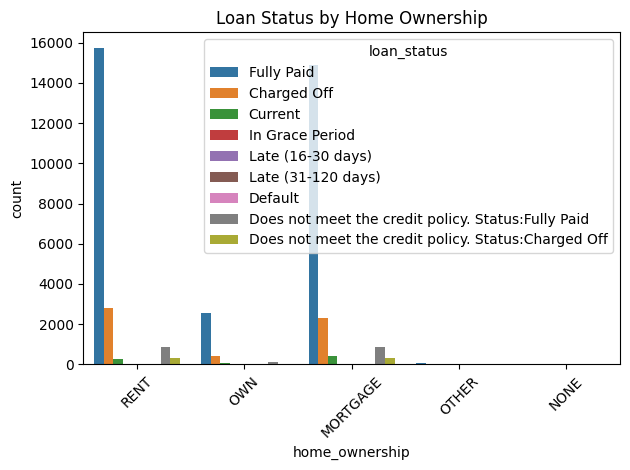

In [16]:
#Checking relation between loan status and home ownership
sns.countplot(data=df_cat, x='home_ownership', hue='loan_status')
plt.title('Loan Status by Home Ownership')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
#Combining classes OWN and MORTAGE To HOMEOWNER, RENT, and dropping rows with OTHER and NONE.
df_cat['home_ownership'] = df_cat['home_ownership'].replace(['OWN', 'MORTGAGE'], 'HOMEOWNER')
df_cat['home_ownership'] = df_cat['home_ownership'].replace(['OTHER', 'NONE'], np.nan)
#Dropping rows with NaN values
df_cat = df_cat.dropna(subset=['home_ownership'])
#Checking the value counts
df_cat['home_ownership'].value_counts()

,count
home_ownership,
HOMEOWNER,22092
RENT,20010


In [18]:
#Checking the shape of the data
print("\nShape of the data after combining home ownership classes:\n", df_cat.shape)


Shape of the data after combining home ownership classes:
 (42102, 35)


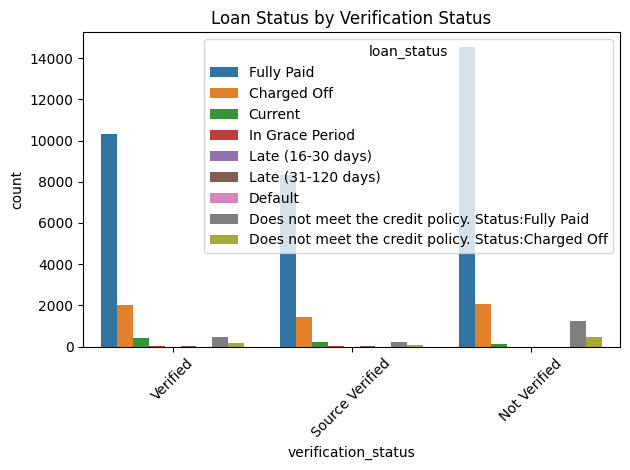

In [19]:
#Checking relation between loan status and verification status
sns.countplot(data=df_cat, x='verification_status', hue='loan_status')
plt.title('Loan Status by Verification Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
#Check for value counts
df_cat['verification_status'].value_counts()

,count
verification_status,
Not Verified,18454
Verified,13386
Source Verified,10262


In [21]:
#Replace VERIFIED with VERIFIED - source and VERIFIED - not verified
df_cat['verification_status'] = df_cat['verification_status'].replace(['Verified', 'Source Verified'], 'Verified')
#Check for value counts
df_cat['verification_status'].value_counts()

,count
verification_status,
Verified,23648
Not Verified,18454


In [22]:
#Checking the data types of the columns
df_cat.dtypes

,0
member_id,float64
loan_amnt,float64
funded_amnt,float64
funded_amnt_inv,float64
term,float64
int_rate,float64
installment,float64
home_ownership,object
annual_inc,float64
verification_status,object


In [23]:
df_quant = df_cat.copy()
#Checking the shape of the data
print("\nShape of the data for quantitative features cleaning:\n", df_quant.shape)


Shape of the data for quantitative features cleaning:
 (42102, 35)


3.3 Cleaning Quantitative features

In [24]:
df_quant.select_dtypes(exclude=['object']).columns

Index(['member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term',
       'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_amnt', 'collections_12_mths_ex_med', 'policy_code',
       'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt',
       'tax_liens'],
      dtype='object')

In [25]:
#Removing quantitative columns with only one unique value
for col in df_quant.columns:
    if len(df_quant[col].value_counts()) == 1:
        print(f"Dropping column '{col}' as it has only one unique value.")
        df_quant = df_quant.drop(col, axis=1)
df_quant.head(10)

Dropping column 'collections_12_mths_ex_med' as it has only one unique value.
Dropping column 'policy_code' as it has only one unique value.
Dropping column 'chargeoff_within_12_mths' as it has only one unique value.
Dropping column 'delinq_amnt' as it has only one unique value.
Dropping column 'tax_liens' as it has only one unique value.


,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,home_ownership,annual_inc,verification_status,...,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,acc_now_delinq
0,1296599.0,5000.0,5000.0,4975.0,36.0,0.1065,162.87,RENT,24000.0,Verified,...,0.0,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,171.62,0.0
1,1314167.0,2500.0,2500.0,2500.0,60.0,0.1527,59.83,RENT,30000.0,Verified,...,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,0.0
2,1313524.0,2400.0,2400.0,2400.0,36.0,0.1596,84.33,RENT,12252.0,Not Verified,...,0.0,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,649.91,0.0
3,1277178.0,10000.0,10000.0,10000.0,36.0,0.1349,339.31,RENT,49200.0,Verified,...,0.0,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,357.48,0.0
4,1311748.0,3000.0,3000.0,3000.0,60.0,0.1269,67.79,RENT,80000.0,Verified,...,335.1,3716.700000,3716.70,2664.90,1051.80,0.00,0.00,0.00,67.79,0.0
5,1311441.0,5000.0,5000.0,5000.0,36.0,0.0790,156.46,RENT,36000.0,Verified,...,0.0,5632.210000,5632.21,5000.00,632.21,0.00,0.00,0.00,161.03,0.0
6,1304742.0,7000.0,7000.0,7000.0,60.0,0.1596,170.08,RENT,47004.0,Not Verified,...,0.0,10137.840010,10137.84,7000.00,3137.84,0.00,0.00,0.00,1313.76,0.0
7,1288686.0,3000.0,3000.0,3000.0,36.0,0.1864,109.43,RENT,48000.0,Verified,...,0.0,3939.135294,3939.14,3000.00,939.14,0.00,0.00,0.00,111.34,0.0
8,1306957.0,5600.0,5600.0,5600.0,60.0,0.2128,152.39,HOMEOWNER,40000.0,Verified,...,0.0,646.020000,646.02,162.02,294.94,0.00,189.06,2.09,152.39,0.0
9,1306721.0,5375.0,5375.0,5350.0,60.0,0.1269,121.45,RENT,15000.0,Verified,...,0.0,1476.190000,1469.34,673.48,533.42,0.00,269.29,2.52,121.45,0.0


In [26]:
#Removing member_id column as it does not contribute of prediction
df_quant.drop(columns=['member_id'], axis=1, inplace=True)

In [27]:
print("\nShape of the data after dropping member_id column:\n", df_quant.shape)
df_quant.head(10)


Shape of the data after dropping member_id column:
 (42102, 29)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,home_ownership,annual_inc,verification_status,loan_status,...,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,acc_now_delinq
0,5000.0,5000.0,4975.0,36.0,0.1065,162.87,RENT,24000.0,Verified,Fully Paid,...,0.0,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,171.62,0.0
1,2500.0,2500.0,2500.0,60.0,0.1527,59.83,RENT,30000.0,Verified,Charged Off,...,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,0.0
2,2400.0,2400.0,2400.0,36.0,0.1596,84.33,RENT,12252.0,Not Verified,Fully Paid,...,0.0,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,649.91,0.0
3,10000.0,10000.0,10000.0,36.0,0.1349,339.31,RENT,49200.0,Verified,Fully Paid,...,0.0,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,357.48,0.0
4,3000.0,3000.0,3000.0,60.0,0.1269,67.79,RENT,80000.0,Verified,Current,...,335.1,3716.700000,3716.70,2664.90,1051.80,0.00,0.00,0.00,67.79,0.0
5,5000.0,5000.0,5000.0,36.0,0.0790,156.46,RENT,36000.0,Verified,Fully Paid,...,0.0,5632.210000,5632.21,5000.00,632.21,0.00,0.00,0.00,161.03,0.0
6,7000.0,7000.0,7000.0,60.0,0.1596,170.08,RENT,47004.0,Not Verified,Fully Paid,...,0.0,10137.840010,10137.84,7000.00,3137.84,0.00,0.00,0.00,1313.76,0.0
7,3000.0,3000.0,3000.0,36.0,0.1864,109.43,RENT,48000.0,Verified,Fully Paid,...,0.0,3939.135294,3939.14,3000.00,939.14,0.00,0.00,0.00,111.34,0.0
8,5600.0,5600.0,5600.0,60.0,0.2128,152.39,HOMEOWNER,40000.0,Verified,Charged Off,...,0.0,646.020000,646.02,162.02,294.94,0.00,189.06,2.09,152.39,0.0
9,5375.0,5375.0,5350.0,60.0,0.1269,121.45,RENT,15000.0,Verified,Charged Off,...,0.0,1476.190000,1469.34,673.48,533.42,0.00,269.29,2.52,121.45,0.0


In [28]:
df_quant.select_dtypes(exclude=['object']).columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_amnt', 'acc_now_delinq'],
      dtype='object')

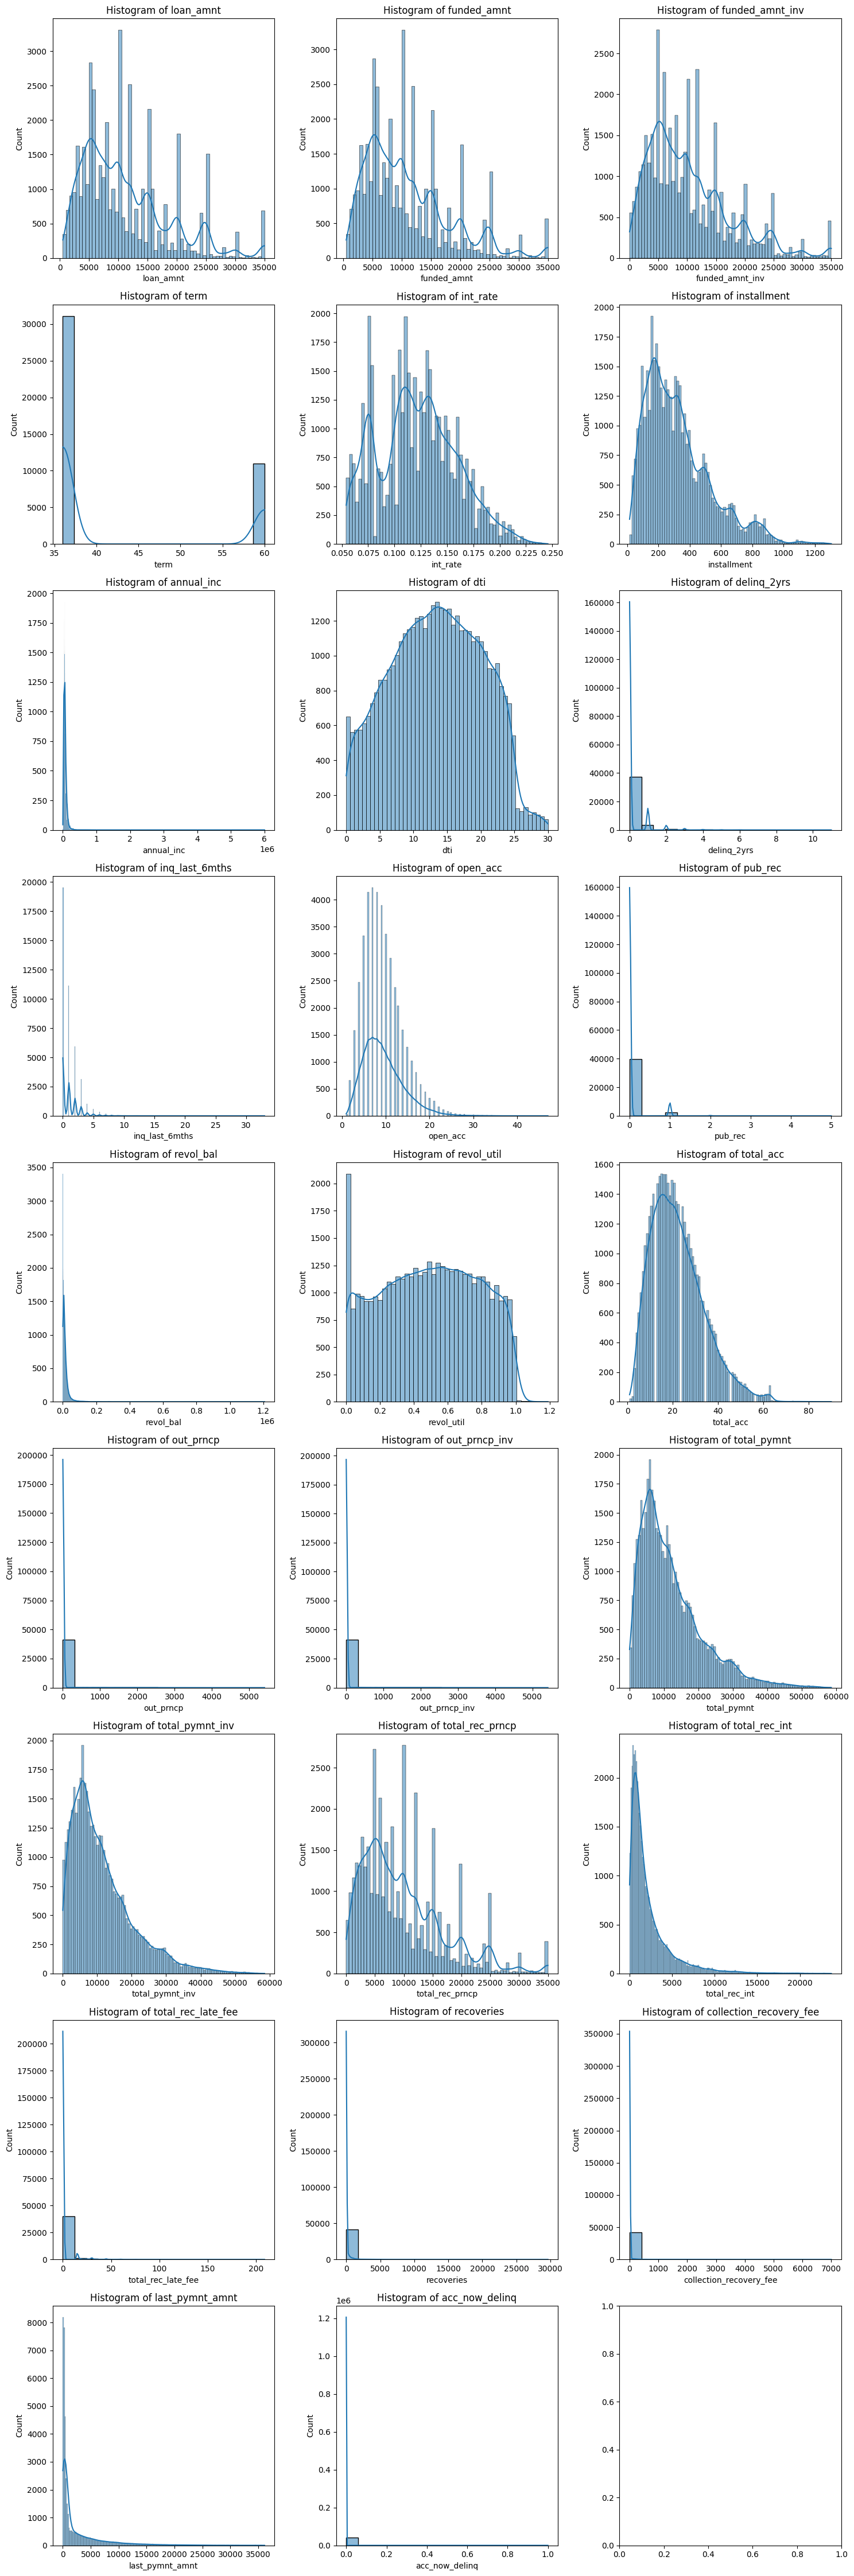

In [29]:
#Checking distribution of each quantitative column
numeric_cols = df_quant.select_dtypes(exclude=['object']).columns

#Plot histograms for numeric columns in 3 columns
num_plots = len(numeric_cols)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easier iteration

for i, col in enumerate(numeric_cols):
    if i < num_plots:
        sns.histplot(df_quant[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {col}')
    else:
        axes[i].axis('off')  # Hide any extra subplots

plt.tight_layout()
plt.show()



In [30]:
#Checking the count distribution of these columns :  'annual_inc', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'out_prncp', 'out_prncp_inv', 'total_rec_late_fee', 'recoveries','collection_recovery_fee', 'acc_now_delinq'

columns = ['annual_inc', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'revol_bal',
           'out_prncp', 'out_prncp_inv', 'total_rec_late_fee', 'recoveries',
           'collection_recovery_fee', 'acc_now_delinq']

for col in columns:
    print(f"\nValue counts for column: {col}")
    print(df_quant[col].value_counts(dropna=False))



Value counts for column: annual_inc
annual_inc
60000.0     1580
50000.0     1105
40000.0      924
45000.0      887
30000.0      876
            ... 
32708.0        1
70346.0        1
69540.0        1
56712.0        1
374000.0       1
Name: count, Length: 5558, dtype: int64

Value counts for column: delinq_2yrs
delinq_2yrs
0.0     37435
1.0      3550
2.0       758
3.0       240
4.0        67
5.0        27
6.0        13
7.0         6
8.0         3
11.0        2
9.0         1
Name: count, dtype: int64

Value counts for column: inq_last_6mths
inq_last_6mths
0.0     19521
1.0     11141
2.0      5931
3.0      3139
4.0      1031
5.0       586
6.0       327
7.0       180
8.0       113
9.0        46
10.0       23
11.0       14
12.0       14
15.0        8
14.0        5
13.0        4
16.0        3
18.0        3
24.0        2
17.0        2
19.0        2
33.0        1
32.0        1
31.0        1
28.0        1
25.0        1
27.0        1
20.0        1
Name: count, dtype: int64

Value counts for col

In [31]:
#Removing quativative columns with only low variance - keeping some low variance columns with little information for now
low_variance_cols = [ 'out_prncp', 'out_prncp_inv', 'acc_now_delinq']
for col in low_variance_cols:
    print(f"Dropping column '{col}' as it has low variance.")
    df_quant = df_quant.drop(col, axis=1)
print("\nShape of the data after dropping low variance columns:\n", df_quant.shape)
#Checking the shape of the data
df_quant.head(10)


#May need to drop the following columns as well - 'delinq_2yrs', 'pub_rec' - but we will keep them for now

Dropping column 'out_prncp' as it has low variance.
Dropping column 'out_prncp_inv' as it has low variance.
Dropping column 'acc_now_delinq' as it has low variance.

Shape of the data after dropping low variance columns:
 (42102, 26)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,home_ownership,annual_inc,verification_status,loan_status,...,revol_util,total_acc,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt
0,5000.0,5000.0,4975.0,36.0,0.1065,162.87,RENT,24000.0,Verified,Fully Paid,...,0.837,9.0,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,171.62
1,2500.0,2500.0,2500.0,60.0,0.1527,59.83,RENT,30000.0,Verified,Charged Off,...,0.094,4.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66
2,2400.0,2400.0,2400.0,36.0,0.1596,84.33,RENT,12252.0,Not Verified,Fully Paid,...,0.985,10.0,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,649.91
3,10000.0,10000.0,10000.0,36.0,0.1349,339.31,RENT,49200.0,Verified,Fully Paid,...,0.210,37.0,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,357.48
4,3000.0,3000.0,3000.0,60.0,0.1269,67.79,RENT,80000.0,Verified,Current,...,0.539,38.0,3716.700000,3716.70,2664.90,1051.80,0.00,0.00,0.00,67.79
5,5000.0,5000.0,5000.0,36.0,0.0790,156.46,RENT,36000.0,Verified,Fully Paid,...,0.283,12.0,5632.210000,5632.21,5000.00,632.21,0.00,0.00,0.00,161.03
6,7000.0,7000.0,7000.0,60.0,0.1596,170.08,RENT,47004.0,Not Verified,Fully Paid,...,0.856,11.0,10137.840010,10137.84,7000.00,3137.84,0.00,0.00,0.00,1313.76
7,3000.0,3000.0,3000.0,36.0,0.1864,109.43,RENT,48000.0,Verified,Fully Paid,...,0.875,4.0,3939.135294,3939.14,3000.00,939.14,0.00,0.00,0.00,111.34
8,5600.0,5600.0,5600.0,60.0,0.2128,152.39,HOMEOWNER,40000.0,Verified,Charged Off,...,0.326,13.0,646.020000,646.02,162.02,294.94,0.00,189.06,2.09,152.39
9,5375.0,5375.0,5350.0,60.0,0.1269,121.45,RENT,15000.0,Verified,Charged Off,...,0.365,3.0,1476.190000,1469.34,673.48,533.42,0.00,269.29,2.52,121.45


3.4 One hot Encoding home_ownership and verfication_Status

In [32]:
#One hot Encoding home_ownership and verfication_Status
df_encode = pd.get_dummies(df_quant, columns=['home_ownership', 'verification_status'], drop_first=True)
#Checking the shape of the data
print("\nShape of the data after one hot encoding:\n", df_encode.shape)

#Rename home_ownership and verification_status columns
df_encode.rename(columns={'home_ownership_RENT': 'home_ownership', 'verification_status_Verified': 'verification_status'}, inplace=True)


Shape of the data after one hot encoding:
 (42102, 26)


In [33]:
df_encode.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'annual_inc', 'loan_status', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_amnt', 'home_ownership',
       'verification_status'],
      dtype='object')

## **Do feature engineering for 'term'  if 36 - 0 else 1 , making 3 categorical features**

In [34]:

# Convert 'term' column to 0 or 1 based on the condition
try:
  df_encode['term_bin'] = df_encode['term'].apply(lambda x: 0 if x <= 36 else 1)
  df_encode.drop(columns=['term'], inplace=True)
except Exception as e:
  print("already converted:", e)



In [35]:
df_encode.head(10)

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,loan_status,dti,delinq_2yrs,inq_last_6mths,...,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,home_ownership,verification_status,term_bin
0,5000.0,5000.0,4975.0,0.1065,162.87,24000.0,Fully Paid,27.65,0.0,1.0,...,5833.84,5000.00,863.16,0.00,0.00,0.00,171.62,True,True,0
1,2500.0,2500.0,2500.0,0.1527,59.83,30000.0,Charged Off,1.00,0.0,5.0,...,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,True,True,1
2,2400.0,2400.0,2400.0,0.1596,84.33,12252.0,Fully Paid,8.72,0.0,2.0,...,3005.67,2400.00,605.67,0.00,0.00,0.00,649.91,True,False,0
3,10000.0,10000.0,10000.0,0.1349,339.31,49200.0,Fully Paid,20.00,0.0,1.0,...,12231.89,10000.00,2214.92,16.97,0.00,0.00,357.48,True,True,0
4,3000.0,3000.0,3000.0,0.1269,67.79,80000.0,Current,17.94,0.0,0.0,...,3716.70,2664.90,1051.80,0.00,0.00,0.00,67.79,True,True,1
5,5000.0,5000.0,5000.0,0.0790,156.46,36000.0,Fully Paid,11.20,0.0,3.0,...,5632.21,5000.00,632.21,0.00,0.00,0.00,161.03,True,True,0
6,7000.0,7000.0,7000.0,0.1596,170.08,47004.0,Fully Paid,23.51,0.0,1.0,...,10137.84,7000.00,3137.84,0.00,0.00,0.00,1313.76,True,False,1
7,3000.0,3000.0,3000.0,0.1864,109.43,48000.0,Fully Paid,5.35,0.0,2.0,...,3939.14,3000.00,939.14,0.00,0.00,0.00,111.34,True,True,0
8,5600.0,5600.0,5600.0,0.2128,152.39,40000.0,Charged Off,5.55,0.0,2.0,...,646.02,162.02,294.94,0.00,189.06,2.09,152.39,False,True,1
9,5375.0,5375.0,5350.0,0.1269,121.45,15000.0,Charged Off,18.08,0.0,0.0,...,1469.34,673.48,533.42,0.00,269.29,2.52,121.45,True,True,1


3.5 Process the target variable

In [36]:
#Checking the value counts of the target variable
df_encode['loan_status'].value_counts()

,count
loan_status,
Fully Paid,33141
Charged Off,5530
Does not meet the credit policy. Status:Fully Paid,1886
Current,781
Does not meet the credit policy. Status:Charged Off,713
In Grace Period,22
Late (31-120 days),17
Late (16-30 days),8
Default,4


In [37]:
#Shape of the data
print("\nShape of the data before dropping some target clasess:\n", df_encode.shape)


Shape of the data before dropping some target clasess:
 (42102, 26)


In [38]:
# Define mapping
status_map = {
    'Fully Paid': 'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
    'Charged Off': 'Charged Off',
    'Does not meet the credit policy. Status:Charged Off': 'Charged Off'
}

# Filter to only the classes you want
df_encode = df_encode[df_encode['loan_status'].isin(status_map.keys())].copy()
df_encode['loan_status_target'] = df_encode['loan_status'].map(status_map)

# For binary classification, we can map 'Fully Paid' to 0 and 'Charged Off' to 1
df_encode['target'] = df_encode['loan_status_target'].map({'Fully Paid': 0, 'Charged Off': 1})


In [39]:
#Checking the value counts of the target variable
df_encode['target'].value_counts()

,count
target,
0,35027
1,6243


In [40]:
#Shape of the data
print("\nShape of the data after dropping some target clasess:\n", df_encode.shape)
#Drop the original loan_status column and the loan_status_target column
df_encode.drop(columns=['loan_status', 'loan_status_target'], axis=1, inplace=True)


Shape of the data after dropping some target clasess:
 (41270, 28)


In [41]:

#Shape of the data
print("\nShape of the data after dropping some target clasess:\n", df_encode.shape)
df_encode.head(10)


Shape of the data after dropping some target clasess:
 (41270, 26)


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,home_ownership,verification_status,term_bin,target
0,5000.0,5000.0,4975.0,0.1065,162.87,24000.0,27.65,0.0,1.0,3.0,...,5000.00,863.16,0.00,0.00,0.00,171.62,True,True,0,0
1,2500.0,2500.0,2500.0,0.1527,59.83,30000.0,1.00,0.0,5.0,3.0,...,456.46,435.17,0.00,117.08,1.11,119.66,True,True,1,1
2,2400.0,2400.0,2400.0,0.1596,84.33,12252.0,8.72,0.0,2.0,2.0,...,2400.00,605.67,0.00,0.00,0.00,649.91,True,False,0,0
3,10000.0,10000.0,10000.0,0.1349,339.31,49200.0,20.00,0.0,1.0,10.0,...,10000.00,2214.92,16.97,0.00,0.00,357.48,True,True,0,0
5,5000.0,5000.0,5000.0,0.0790,156.46,36000.0,11.20,0.0,3.0,9.0,...,5000.00,632.21,0.00,0.00,0.00,161.03,True,True,0,0
6,7000.0,7000.0,7000.0,0.1596,170.08,47004.0,23.51,0.0,1.0,7.0,...,7000.00,3137.84,0.00,0.00,0.00,1313.76,True,False,1,0
7,3000.0,3000.0,3000.0,0.1864,109.43,48000.0,5.35,0.0,2.0,4.0,...,3000.00,939.14,0.00,0.00,0.00,111.34,True,True,0,0
8,5600.0,5600.0,5600.0,0.2128,152.39,40000.0,5.55,0.0,2.0,11.0,...,162.02,294.94,0.00,189.06,2.09,152.39,False,True,1,1
9,5375.0,5375.0,5350.0,0.1269,121.45,15000.0,18.08,0.0,0.0,2.0,...,673.48,533.42,0.00,269.29,2.52,121.45,True,True,1,1
10,6500.0,6500.0,6500.0,0.1465,153.45,72000.0,16.12,0.0,2.0,14.0,...,6500.00,1178.02,0.00,0.00,0.00,1655.54,False,False,1,0


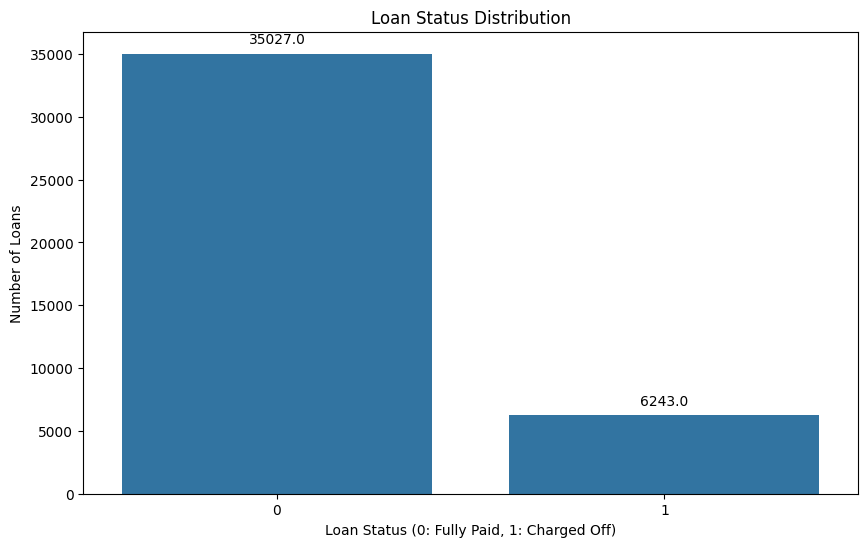

In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=df_encode)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (0: Fully Paid, 1: Charged Off)')
plt.ylabel('Number of Loans')

# Print the values
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()


3.4 Feature Selection

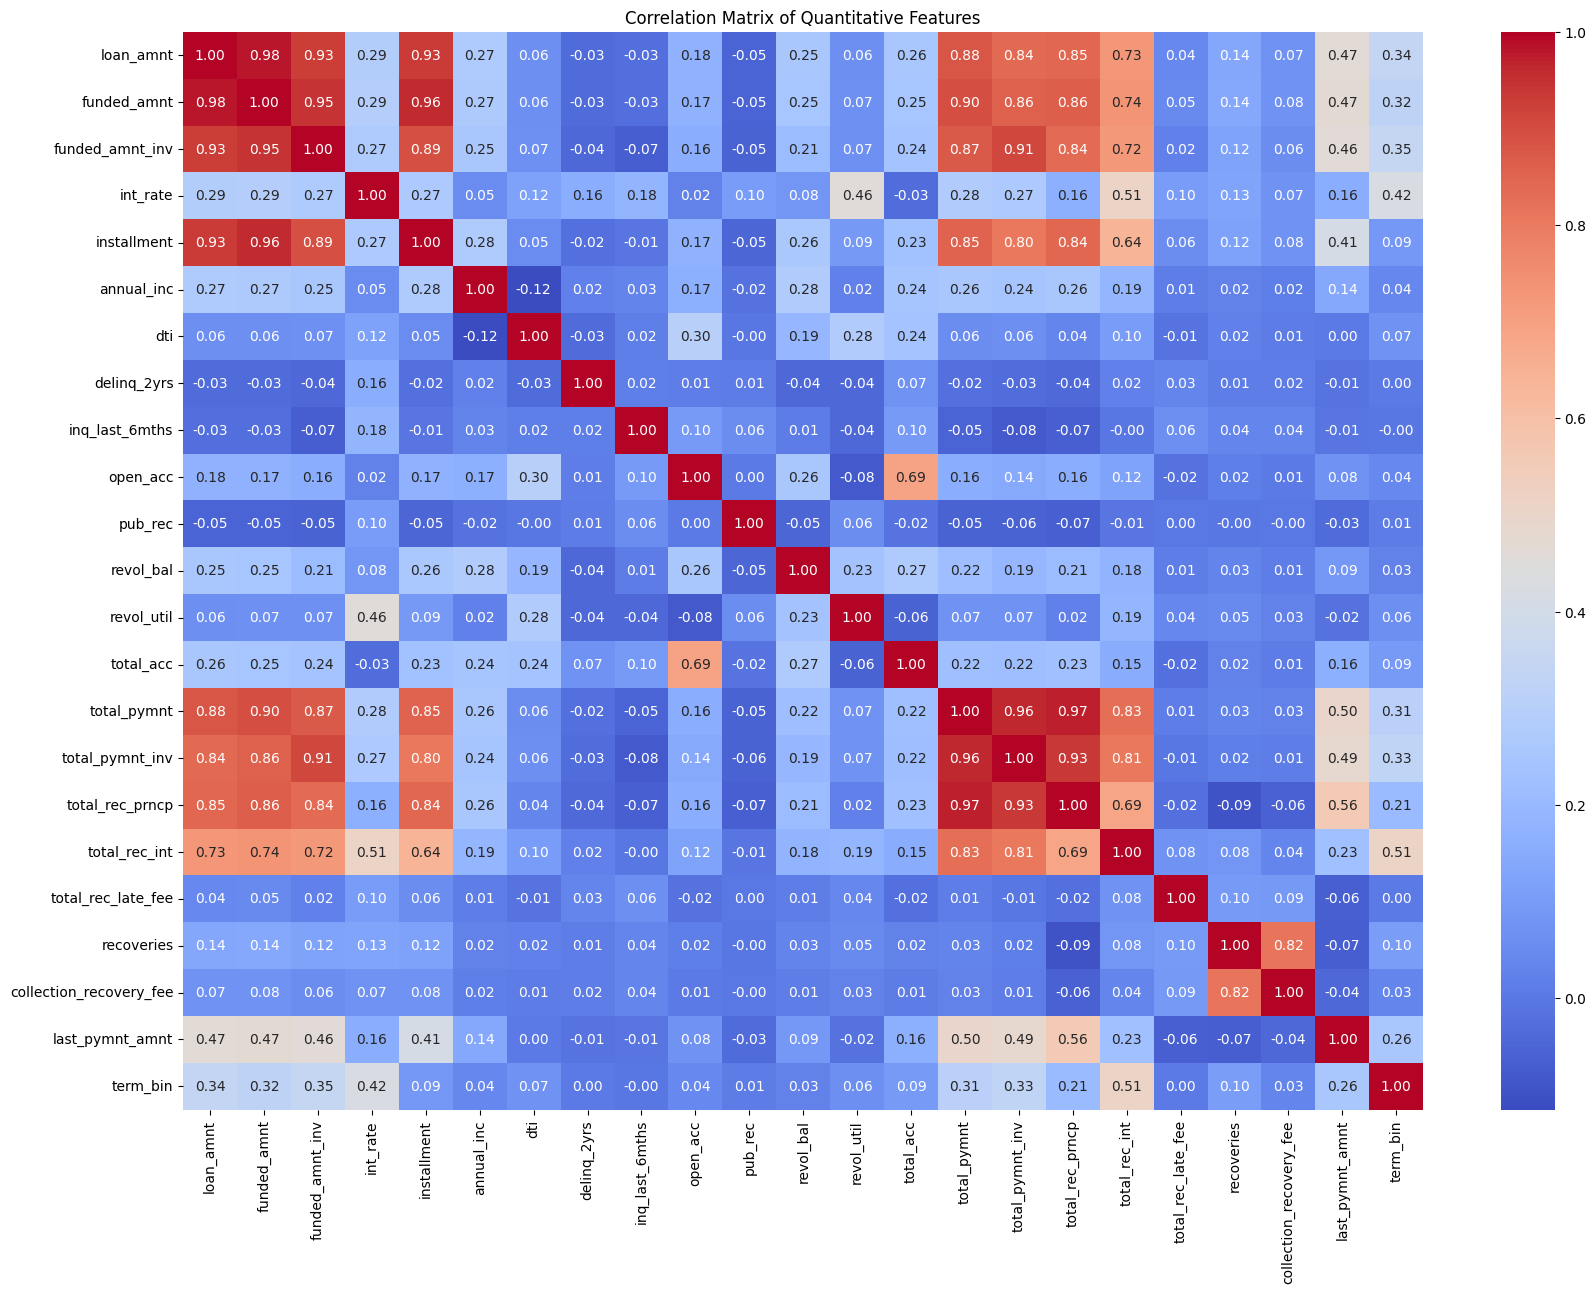

In [43]:
#Checking multicollinearity
columns = df_encode.drop(columns=['target', 'home_ownership', 'verification_status'], errors='ignore').columns
corr_matrix = df_encode[columns].corr()

plt.figure(figsize=(20, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Quantitative Features')
plt.show()


In [44]:
df_encode.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_amnt', 'home_ownership', 'verification_status', 'term_bin',
       'target'],
      dtype='object')

In [45]:
df_modelling = df_encode.copy()

In [46]:
#Checking the shape of the data
print("\nShape of the data for modelling:\n", df_modelling.shape)
df_modelling.head(10)


Shape of the data for modelling:
 (41270, 26)


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,home_ownership,verification_status,term_bin,target
0,5000.0,5000.0,4975.0,0.1065,162.87,24000.0,27.65,0.0,1.0,3.0,...,5000.00,863.16,0.00,0.00,0.00,171.62,True,True,0,0
1,2500.0,2500.0,2500.0,0.1527,59.83,30000.0,1.00,0.0,5.0,3.0,...,456.46,435.17,0.00,117.08,1.11,119.66,True,True,1,1
2,2400.0,2400.0,2400.0,0.1596,84.33,12252.0,8.72,0.0,2.0,2.0,...,2400.00,605.67,0.00,0.00,0.00,649.91,True,False,0,0
3,10000.0,10000.0,10000.0,0.1349,339.31,49200.0,20.00,0.0,1.0,10.0,...,10000.00,2214.92,16.97,0.00,0.00,357.48,True,True,0,0
5,5000.0,5000.0,5000.0,0.0790,156.46,36000.0,11.20,0.0,3.0,9.0,...,5000.00,632.21,0.00,0.00,0.00,161.03,True,True,0,0
6,7000.0,7000.0,7000.0,0.1596,170.08,47004.0,23.51,0.0,1.0,7.0,...,7000.00,3137.84,0.00,0.00,0.00,1313.76,True,False,1,0
7,3000.0,3000.0,3000.0,0.1864,109.43,48000.0,5.35,0.0,2.0,4.0,...,3000.00,939.14,0.00,0.00,0.00,111.34,True,True,0,0
8,5600.0,5600.0,5600.0,0.2128,152.39,40000.0,5.55,0.0,2.0,11.0,...,162.02,294.94,0.00,189.06,2.09,152.39,False,True,1,1
9,5375.0,5375.0,5350.0,0.1269,121.45,15000.0,18.08,0.0,0.0,2.0,...,673.48,533.42,0.00,269.29,2.52,121.45,True,True,1,1
10,6500.0,6500.0,6500.0,0.1465,153.45,72000.0,16.12,0.0,2.0,14.0,...,6500.00,1178.02,0.00,0.00,0.00,1655.54,False,False,1,0


### DO EDA

In [47]:
df_modelling.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_amnt', 'home_ownership', 'verification_status', 'term_bin',
       'target'],
      dtype='object')

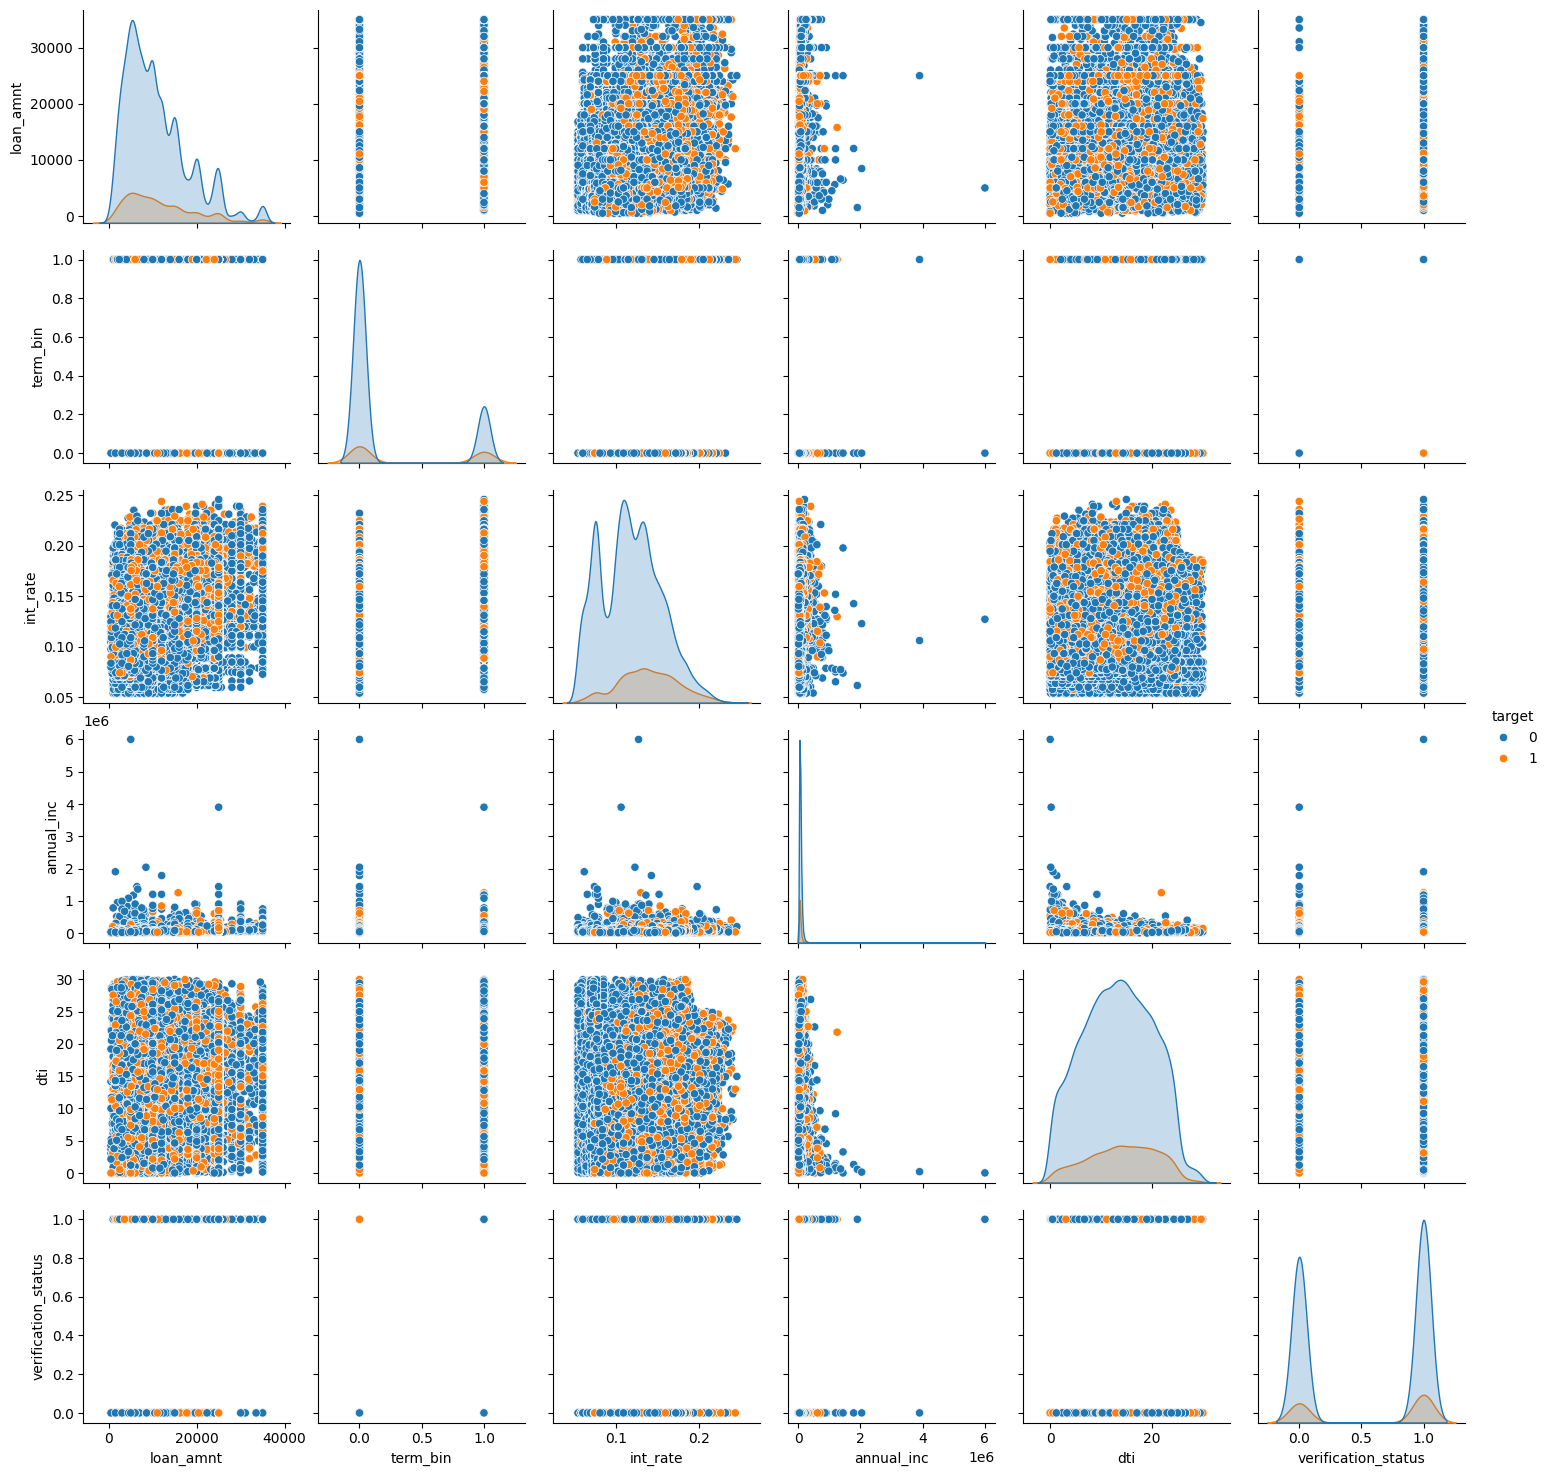

In [48]:
# prompt: do pairplot for columns=['loan_amnt', 'term_bin', 'int_rate', 'annual_inc', 'dti','verification_status'] with hue as 'target'

import matplotlib.pyplot as plt
sns.pairplot(df_modelling, vars=['loan_amnt', 'term_bin', 'int_rate', 'annual_inc', 'dti','verification_status'], hue='target')
plt.show()


## **Feature Scaling**

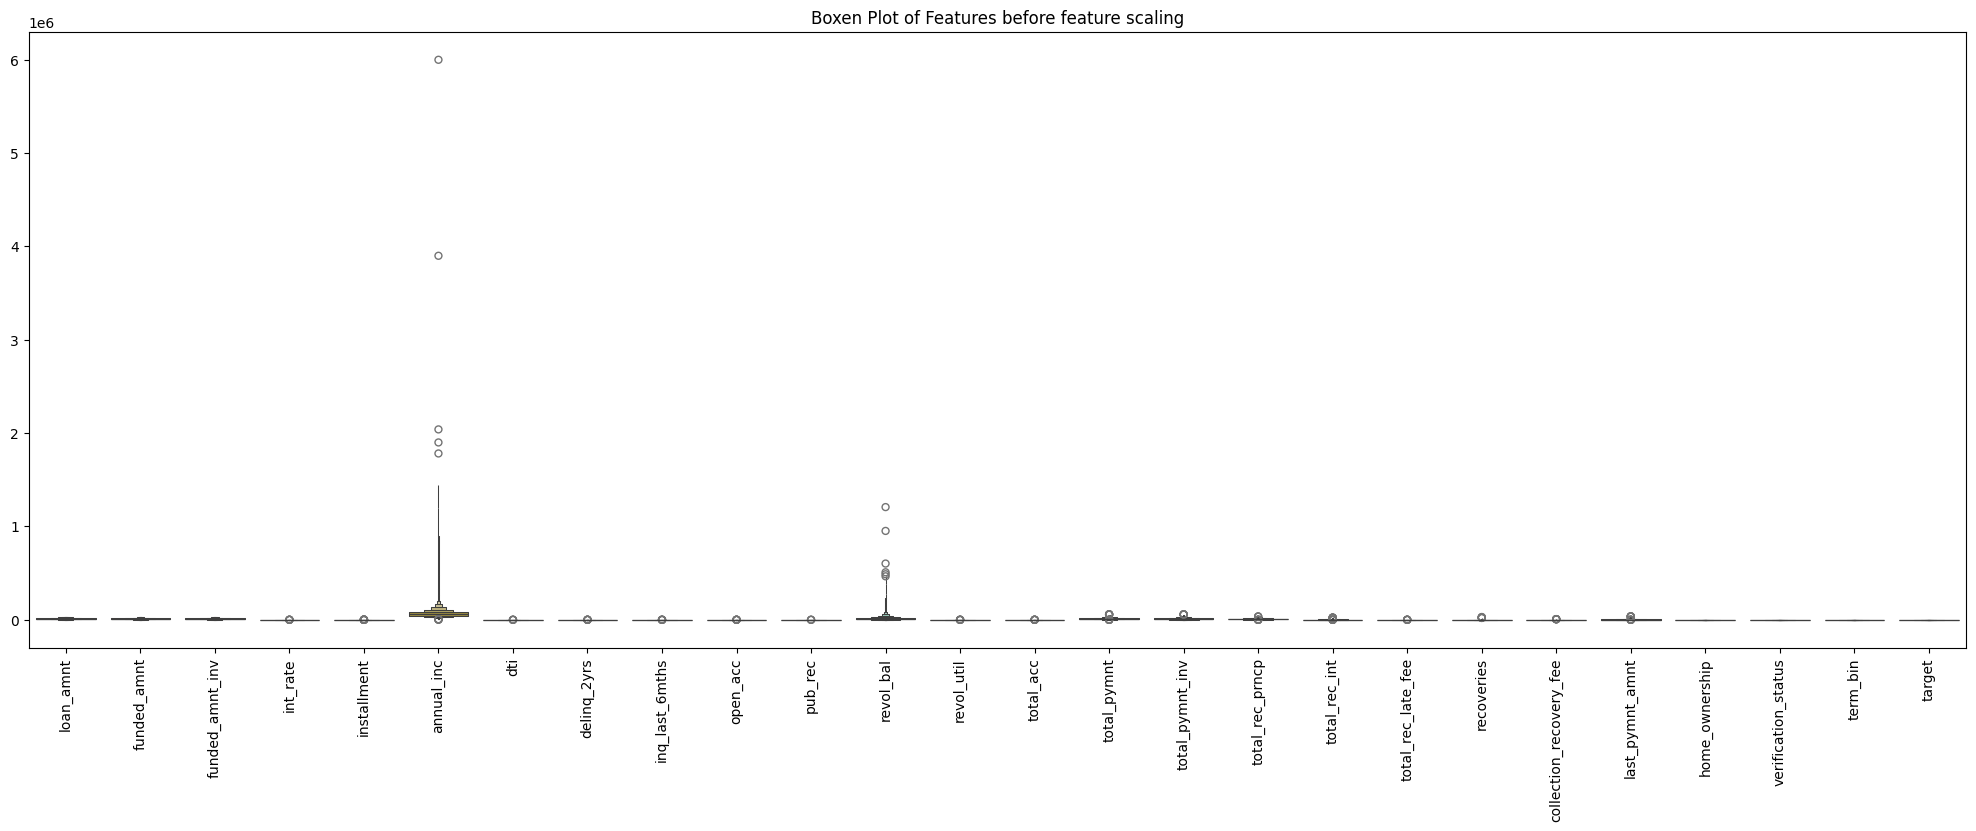

In [49]:
plt.figure(figsize=(25,8))
sns.boxenplot(data=df_modelling)
plt.title('Boxen Plot of Features before feature scaling')
plt.xticks(rotation=90)
plt.show()

In [50]:
df_modelling.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,term_bin,target
count,41270.000000,41270.000000,41270.000000,41270.000000,41270.000000,4.127000e+04,41270.000000,41270.000000,41270.000000,41270.000000,...,41270.000000,41270.000000,41270.000000,41270.000000,41270.000000,41270.000000,41270.000000,41270.000000,41270.000000,41270.000000
mean,10995.174461,10731.454446,10061.819444,0.120984,321.697361,6.903362e+04,13.369294,0.151442,1.080349,9.343785,...,11826.125902,11130.444359,9577.608185,2145.913434,1.491624,101.112752,14.047703,2674.859708,0.245772,0.151272
std,7329.106851,7068.818716,7037.865399,0.036892,208.595974,6.441484e+04,6.721257,0.506936,1.521686,4.494443,...,8837.322575,8761.576612,7003.123036,2421.315610,7.712950,722.757972,161.009416,4430.520110,0.430549,0.358318
min,500.000000,500.000000,0.000000,0.054200,15.670000,1.896000e+03,0.000000,0.000000,0.000000,1.000000,...,33.730000,0.000000,0.000000,6.220000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5100.000000,5000.000000,4950.000000,0.095100,165.460000,4.000000e+04,8.200000,0.000000,0.000000,6.000000,...,5449.747735,4807.375000,4400.000000,651.080000,0.000000,0.000000,0.000000,213.315000,0.000000,0.000000
50%,9600.000000,9450.000000,8400.000000,0.119700,276.620000,5.870200e+04,13.470000,0.000000,1.000000,9.000000,...,9587.912783,8887.355000,8000.000000,1316.710000,0.000000,0.000000,0.000000,546.595000,0.000000,0.000000
75%,15000.000000,15000.000000,14000.000000,0.146500,424.965000,8.200000e+04,18.680000,0.000000,2.000000,12.000000,...,16130.320003,15235.655000,13000.000000,2705.025000,0.000000,0.000000,0.000000,3304.482500,0.000000,0.000000
max,35000.000000,35000.000000,35000.000000,0.245900,1305.190000,6.000000e+06,29.990000,11.000000,33.000000,47.000000,...,58563.679930,58563.680000,35000.020000,23563.680000,209.000000,29623.350000,7002.190000,36115.200000,1.000000,1.000000


In [51]:
# prompt: do feature scaling I mean stardarization for columns which are in numeric_cols of df_modelling dataset and rename the result as df_modelling_scaled

from sklearn.preprocessing import StandardScaler

numeric_cols = df_modelling.select_dtypes(include=['float64', 'int64']).columns

# Exclude binary/dummy columns (if needed)
binary_cols = [col for col in numeric_cols if set(df_modelling[col].unique()) <= {0, 1}]
continuous_cols = [col for col in numeric_cols if col not in binary_cols]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numeric columns
df_modelling_scaled = df_modelling.copy()  # Create a copy to avoid modifying the original DataFrame
df_modelling_scaled[continuous_cols] = scaler.fit_transform(df_modelling[continuous_cols])


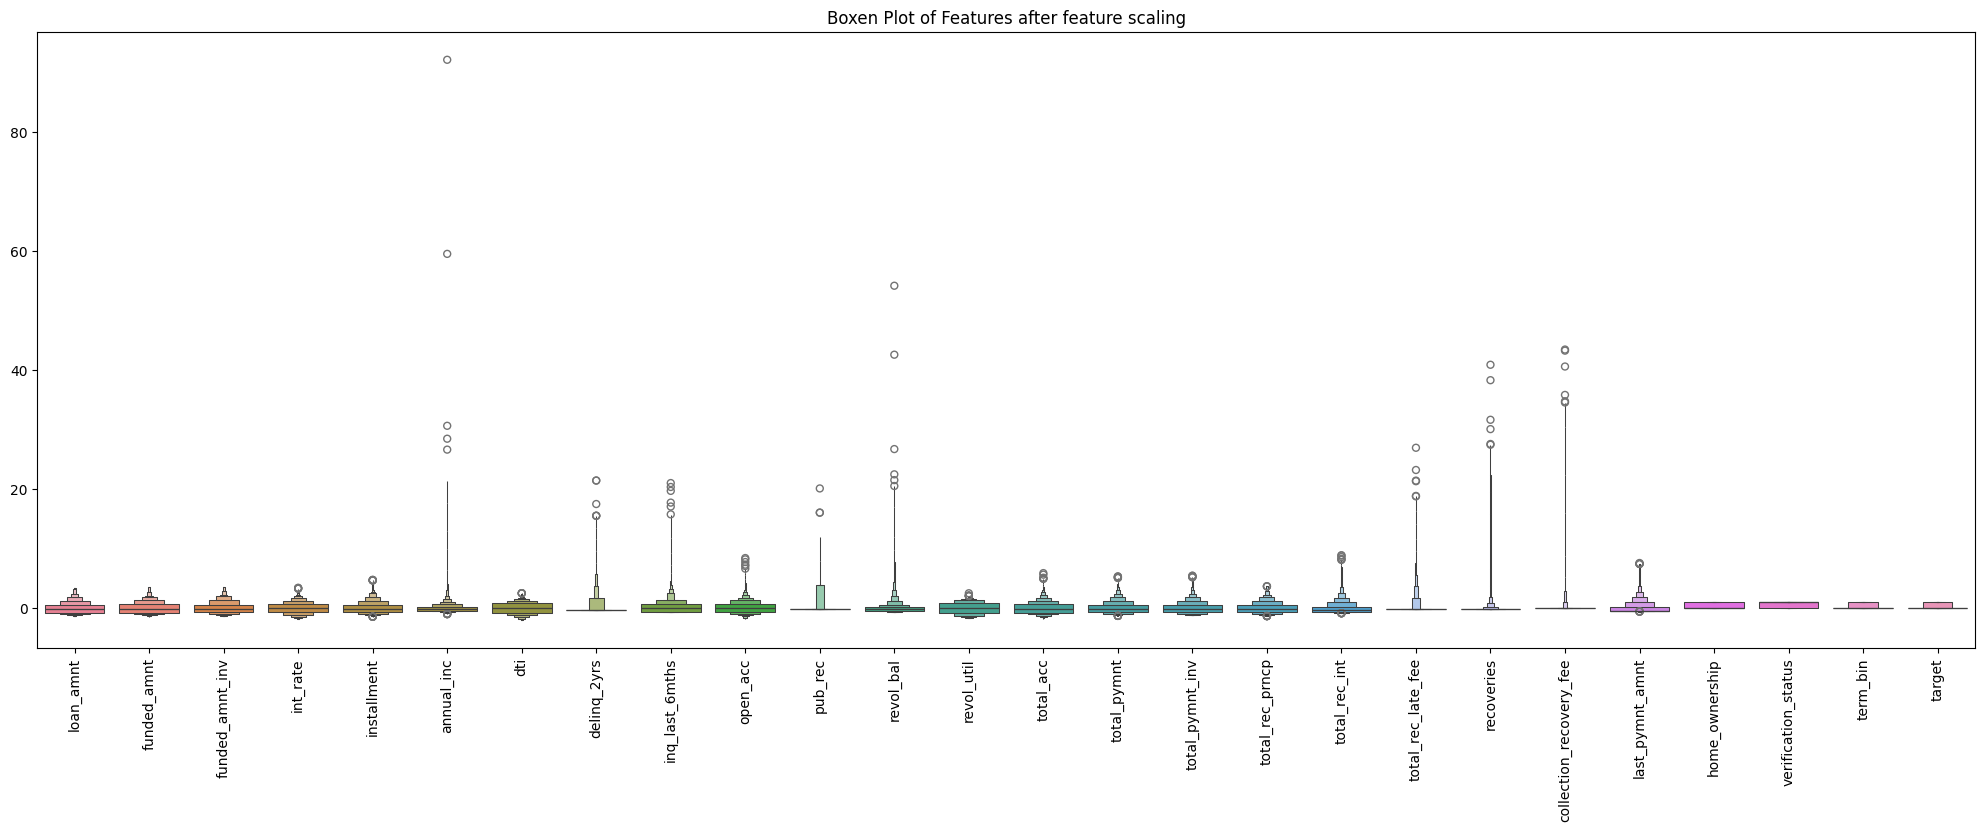

In [52]:
plt.figure(figsize=(25,8))
sns.boxenplot(data=df_modelling_scaled)
plt.title('Boxen Plot of Features after feature scaling')
plt.xticks(rotation=90)
plt.show()

In [53]:
print(df_modelling_scaled.shape)
df_modelling_scaled.head(10)

(41270, 26)


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,home_ownership,verification_status,term_bin,target
0,-0.818005,-0.810818,-0.722787,-0.392613,-0.761421,-0.699127,2.124733,-0.298743,-0.052803,-1.411490,...,-0.653660,-0.529782,-0.193394,-0.139900,-0.087249,-0.565006,True,True,0,0
1,-1.159115,-1.164488,-1.074461,0.859692,-1.255396,-0.605980,-1.840347,-0.298743,2.575891,-1.411490,...,-1.302456,-0.706543,-0.193394,0.022092,-0.080355,-0.576734,True,True,1,1
2,-1.172759,-1.178635,-1.088670,1.046725,-1.137943,-0.881510,-0.691738,-0.298743,0.604370,-1.633990,...,-1.024928,-0.636126,-0.193394,-0.139900,-0.087249,-0.457051,True,False,0,0
3,-0.135786,-0.103477,-0.008784,0.377202,0.084435,-0.307908,0.986540,-0.298743,-0.052803,0.146008,...,0.060316,0.028500,2.006828,-0.139900,-0.087249,-0.523055,True,True,0,0
5,-0.818005,-0.810818,-0.719235,-1.138032,-0.792150,-0.512832,-0.322755,-0.298743,1.261544,-0.076492,...,-0.653660,-0.625165,-0.193394,-0.139900,-0.087249,-0.567396,True,True,0,0
6,-0.545117,-0.527882,-0.435055,1.046725,-0.726856,-0.342000,1.508770,-0.298743,-0.052803,-0.521491,...,-0.368070,0.409669,-0.193394,-0.139900,-0.087249,-0.307214,True,False,1,0
7,-1.090893,-1.093754,-1.003416,1.773170,-1.017613,-0.326538,-1.193139,-0.298743,0.604370,-1.188991,...,-0.939251,-0.498402,-0.193394,-0.139900,-0.087249,-0.578612,True,True,0,0
8,-0.736139,-0.725937,-0.633981,2.488772,-0.811662,-0.450734,-1.163382,-0.298743,0.604370,0.368507,...,-1.344500,-0.764459,-0.193394,0.121684,-0.074268,-0.569346,False,True,1,1
9,-0.766839,-0.757767,-0.669504,0.160353,-0.959989,-0.838848,0.700875,-0.298743,-0.709977,-1.633990,...,-1.271466,-0.665966,-0.193394,0.232691,-0.071597,-0.576330,True,True,1,1
10,-0.613339,-0.598616,-0.506100,0.691634,-0.806580,0.046052,0.409260,-0.298743,0.604370,1.036006,...,-0.439468,-0.399743,-0.193394,-0.139900,-0.087249,-0.230071,False,False,1,0


4. SMOTE

In [54]:
# Separate predictors and target
X = df_modelling_scaled.drop(columns='target')
y = df_modelling_scaled['target']

# Split into train and test sets (SMOTE is only applied on training data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE on the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [55]:
X_train.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_amnt', 'home_ownership', 'verification_status', 'term_bin'],
      dtype='object')

In [56]:
#Check the shape of training and test data
X_train_smote.shape, y_train_smote.shape, X_test.shape, y_test.shape

((56044, 25), (56044,), (8254, 25), (8254,))

In [57]:
#Checking the value counts of the target variable after SMOTE
y_train_smote.value_counts()

,count
target,
1,28022
0,28022


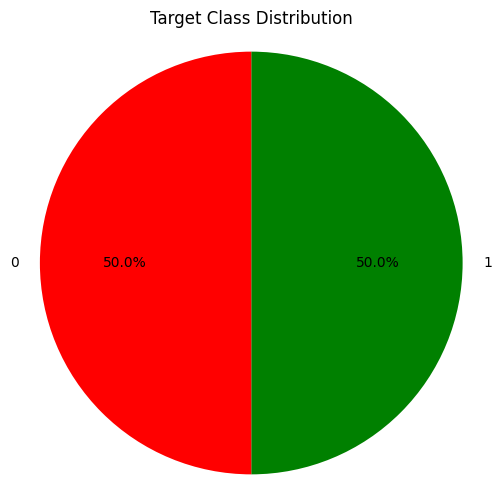

In [58]:
import matplotlib.pyplot as plt

# Count class distribution
smote_counts = y_train_smote.value_counts()
labels = smote_counts.index
sizes = smote_counts.values

# Define colors
colors = ['green', 'red']  # You can switch if needed

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)

plt.title("Target Class Distribution")
plt.axis('equal')  # Keeps it circular
plt.show()

5. Model Training and Evaluation

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate(model, name):
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    return model

In [60]:
# 1. KNN
knn = train_and_evaluate(KNeighborsClassifier(n_neighbors=5), "K-Nearest Neighbors")

# 2. Logistic
logistic = train_and_evaluate(LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression")

# 3. SVM
svm = train_and_evaluate(SVC(kernel='rbf', probability=True), "Support Vector Machine")

# 4. Decision Tree
dt = train_and_evaluate(DecisionTreeClassifier(random_state=42), "Decision Tree")

# 5. Random Forest (with feature importance)
rf = train_and_evaluate(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest")

# 6. XGBoost
xgb = train_and_evaluate(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), "XGBoost")

# 7. AdaBoost
ada = train_and_evaluate(AdaBoostClassifier(n_estimators=100, random_state=42), "AdaBoost")

#8. Artificial Neural Network (MLP)
ann = train_and_evaluate(
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    "Artificial Neural Network (ANN)"
)



K-Nearest Neighbors Accuracy: 0.8824
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7005
           1       0.58      0.81      0.68      1249

    accuracy                           0.88      8254
   macro avg       0.77      0.85      0.80      8254
weighted avg       0.91      0.88      0.89      8254


Logistic Regression Accuracy: 0.9971
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7005
           1       1.00      0.98      0.99      1249

    accuracy                           1.00      8254
   macro avg       1.00      0.99      0.99      8254
weighted avg       1.00      1.00      1.00      8254


Support Vector Machine Accuracy: 0.9925
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7005
           1       0.99      0.96      0.97      1249

    accuracy                           0.99      8254
   macro av

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:57:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Accuracy: 0.9984
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7005
           1       1.00      0.99      0.99      1249

    accuracy                           1.00      8254
   macro avg       1.00      0.99      1.00      8254
weighted avg       1.00      1.00      1.00      8254


AdaBoost Accuracy: 0.9945
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      7005
           1       1.00      0.97      0.98      1249

    accuracy                           0.99      8254
   macro avg       0.99      0.98      0.99      8254
weighted avg       0.99      0.99      0.99      8254


Artificial Neural Network (ANN) Accuracy: 0.9971
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7005
           1       1.00      0.98      0.99      1249

    accuracy                           1.00      8254
   macro avg       1.00  

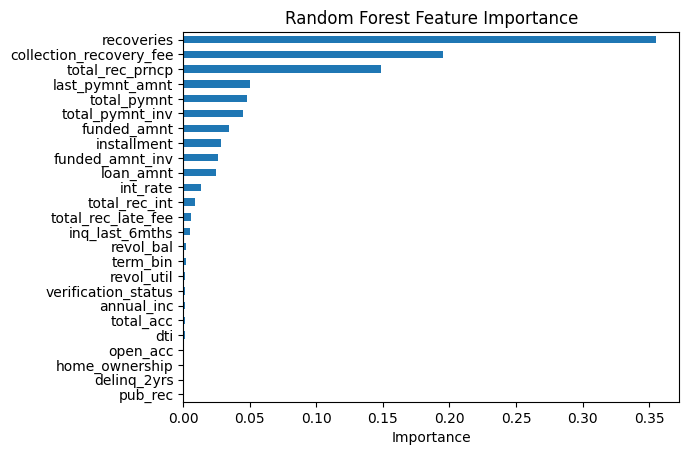

In [61]:
feature_importances = pd.Series(rf.feature_importances_, index=X_train_smote.columns)
feature_importances_sorted = feature_importances.sort_values(ascending=False)
feature_importances_sorted.plot(kind='barh', title='Random Forest Feature Importance')
plt.xlabel("Importance")
plt.gca().invert_yaxis()  # To show the most important feature at the top
plt.show()


# According to both random forest and Logistic regression, Last payment amount is the most crucial feature to identify the loan default

## 5-fold cross validation with hyperparameter tuning on lambda for lasso

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# λ values and their inverses
lambdas = [0.001, 0.01, 0.1, 1, 10, 100]
Cs = [1 / l for l in lambdas]
feature_names = X_train_smote.columns

# Initialize lists for storing coefficients and accuracies
lasso_coefs, lasso_accs = [], []
ridge_coefs, ridge_accs = [], []

# Lasso
for C in Cs:
    model_l1 = LogisticRegression(max_iter=300,penalty='l1', C=C, solver='liblinear')
    acc = cross_val_score(model_l1, X_train_smote, y_train_smote, cv=5, scoring='accuracy').mean()
    model_l1.fit(X_train_smote, y_train_smote)
    lasso_coefs.append(model_l1.coef_[0])
    lasso_accs.append(acc)

# Ridge
for C in Cs:
    model_l2 = LogisticRegression(max_iter=300,penalty='l2', C=C, solver='liblinear')
    acc = cross_val_score(model_l2, X_train_smote, y_train_smote, cv=5, scoring='accuracy').mean()
    model_l2.fit(X_train_smote, y_train_smote)
    ridge_coefs.append(model_l2.coef_[0])
    ridge_accs.append(acc)

# Create DataFrames: λ as index, accuracy as first column
lasso_coef_df = pd.DataFrame(lasso_coefs, columns=feature_names, index=[f"λ={l}" for l in lambdas])
ridge_coef_df = pd.DataFrame(ridge_coefs, columns=feature_names, index=[f"λ={l}" for l in lambdas])

lasso_coef_df.insert(0, 'Accuracy', lasso_accs)
ridge_coef_df.insert(0, 'Accuracy', ridge_accs)

# Display
print("\n📌 Lasso Coefficient Table:\n")


lasso_coef_df.head(10)

In [ ]:
zero_counts = (lasso_coef_df.drop(columns='Accuracy') == 0).sum(axis=1)
print("\nNumber of zero coefficients at each λ:")
print(zero_counts)

In [ ]:
print("\n📌 Ridge Coefficient Table:\n")
ridge_coef_df.head(10)